# Rectified Image Processing for Thermal Landscapes Project
### Roan Camp
 PB 6/22/22 updated by EH 6/23/26
 
Reads in rectified multiband thermal images from each site and looks for images that overlap with shapefiles of inside/outside the exclosures. Extracts metrics from thermal images for analysis.

##### Weird Things about Roan Camp
- The roan camp shapefile is in WGS84 (have to convert to UTM)
- The roan camp shapefile has 2 columns for treatments: 
    - "Treatment" which is either "Inside"/"Outside"
    - "TopoPositi" which is either "Upland"/"Lowland"

In [1]:
import rasterio as rio
import numpy as np
import geopandas as gpd
from pathlib import Path
import xarray as xr
import rioxarray as rioxr
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import pandas as pd
import warnings
import seaborn as sns
from osgeo import gdal

# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 11})

# # # USER INPUTS

# Set site/project string for output figures and stats
projstr = 'RoanCamp'
mast_path = '/n/davies_lab/Lab/shared_projects/ThermalLandscapes/ThermalLandscapes'
# Set figure directory for output figures
figdir = Path(f'{mast_path}/out/figs/test/{projstr}/')
if not figdir.exists():
    figdir.mkdir()

# Define inputs
img_dir = Path('/n/davies_lab/Lab/data/Remote_sensing_data/Products_remote_sensing_data/Africa/South Africa/Kruger/Exclosures/Roan_CampEP/raster/thermal/rectified_images')
shp_f = Path(f"{mast_path}/data/in/Polygons_AD_current/RoanCamp_polygon.shp")

# Set threshold of overlap tolerance btwn images
threshold = 0.25

# Set merged product dir for the project
# used for opening up CHM and other lidar data files
mergedprodstr = '2020-12-04_RoanCamp'
mpdir = Path(f'/n/davies_lab/Lab/data/Remote_sensing_data/Products_merged_remote_sensing_data/{mergedprodstr}/')
     
# # # END USER INPUTS

In [2]:
# Set inputs using user inputs

# Set hue order for plotting
exclosure_hues=["Outside", "Inside"]
topo_hues = ["Upland", "Lowland"]

# Load shapefile
shp = gpd.read_file(shp_f)

# Reproject Shapefile to 32736 (if it's not already)
shp = shp.to_crs('EPSG:32736')

# # # Open up corresponding Lidar data files

# Products - CHM, DTM
chmf = [t for t in mpdir.glob('./CHM/*025m*.tif')][0]

CHM = rioxr.open_rasterio(chmf,
                          parse_coordinates=True,
                          masked=True)

dtmf = [t for t in mpdir.glob('./DTM/*025m*.tif')][0]

DTM = rioxr.open_rasterio(dtmf,
                          parse_coordinates=True,
                          masked=True)
# Also, get PAI and Canopy Density Values from a diff folder
# Note, there is 1 set of pickle files per image file
# Note that they are netcdf files, 
# so you need to call the variable when you open it
# # https://rasterio.readthedocs.io/en/latest/topics/datasets.html
gridmetricdir = Path(f'/n/davies_lab/Lab/data/LabLidarScripts/data/out/ThermalLandscapes/{projstr}/grid_metrics')


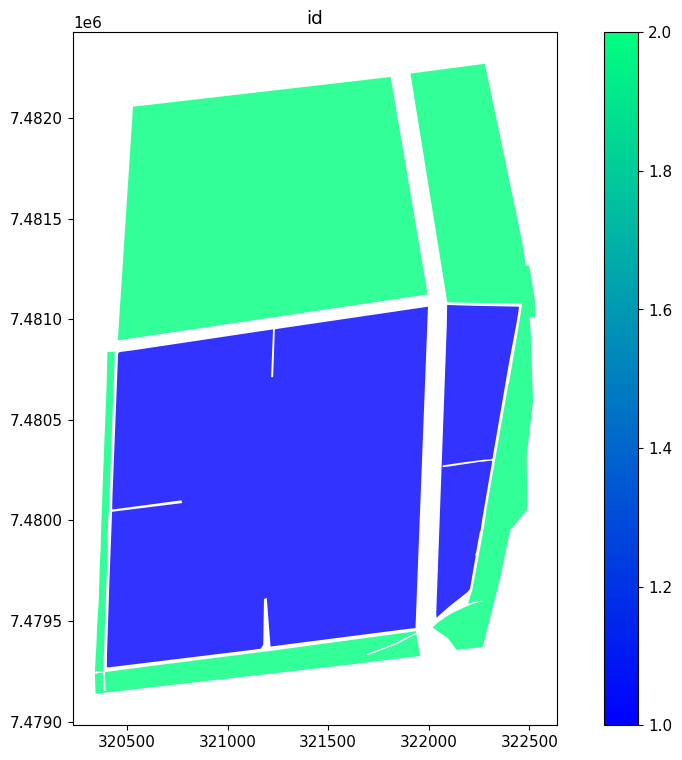

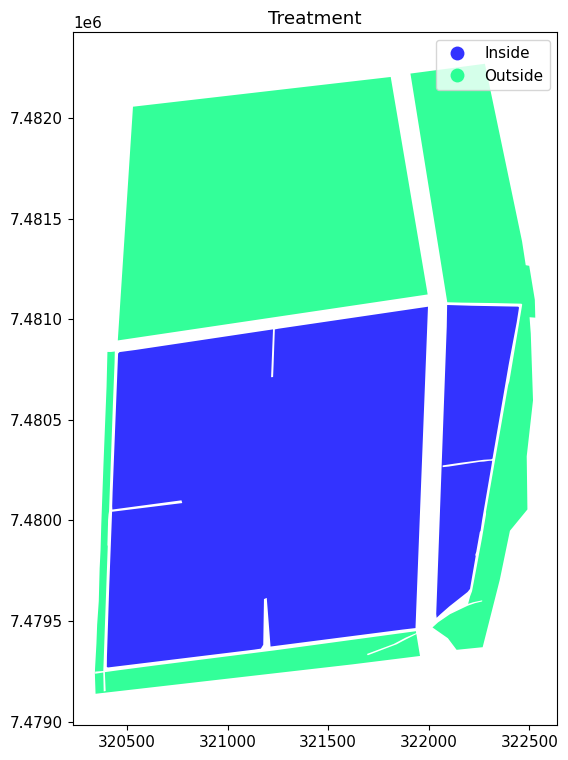

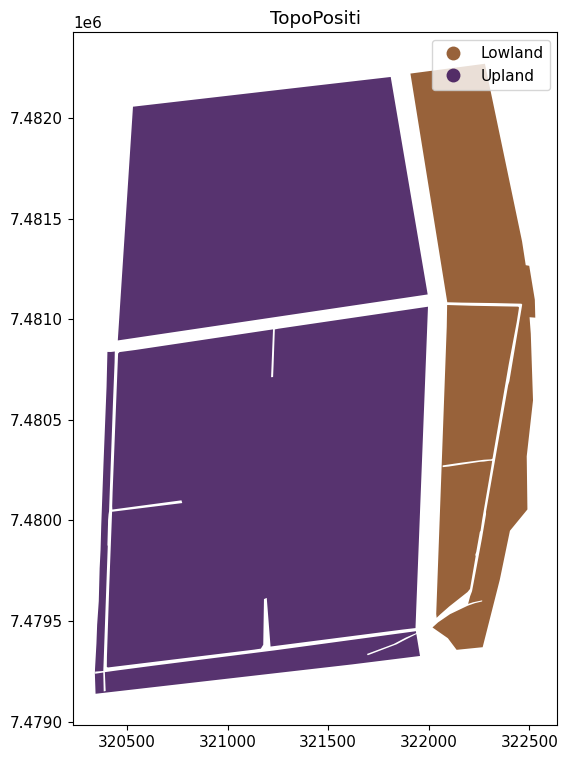

In [3]:
# Plot shapefile attributes
for c in shp.columns[0:-1]:
    if c == 'TopoPositi':
        shp.plot(column=c, legend=True, cmap='PuOr', alpha=0.8)
    else:
        shp.plot(column=c, legend=True, cmap='winter', alpha=0.8)
    plt.title(c)
    plt.savefig(f'{figdir}/ShapefileFeatures_{c}_{projstr}.jpg', dpi=300)

In [4]:
# Define a simple evenness function
# compares the difference in coverage 
def evenness(x):
    # Filter for non-zero values
    X = x.loc[x>=0.01]
    # if more than 2:
    if len(X)>=2:
        # test difference between the values
        # This is the mean difference between the values
        # Divided by the sum of the values
        # 1 - is to make it an descending scale (higher values are better)
        # even = 1 - (np.mean(np.abs(np.diff((X)))) / np.sum(X))
        
        # Actually, screw that! Use coeff. of variation
         # NOTE: -1* need to rescale so scale is descending
        even = -1*(np.std(X)/np.mean(X))
    else:
        even = np.nan
    return even

def classifyVegType(h):
    
    h = np.round(h, 5)
    
    # "bare ground" pixels
    if ((h > -0.03) & (h <= 0.05)):
        veg = 'ground'
        
    # grass
    elif ((h > 0.05) & (h <= 0.5)):
        veg = 'grass'
        
    # shrub
    elif ((h > 0.5) & (h <= 3)):
        veg = 'shrub'
        
    # tree (just using the top bracket to filter out noise points)
    elif ((h > 3) & (h <= 20)):
        veg = 'tree'
        
    else:
        veg = np.nan
        
    return veg


def computeProximityRaster(inf, of):
# Distance to nearest ground from veg type (Ground, Grass, Woody) file
# Copied and pasted from: 
# https://github.com/marcelovilla/gdal-py-snippets/blob/master/scripts/compute_proximity.py
# https://gdal.org/programs/gdal_proximity.html

    ds = gdal.Open(inf, 0)
    
    try:
        
        band = ds.GetRasterBand(1)
        gt = ds.GetGeoTransform()
        sr = ds.GetProjection()
        cols = ds.RasterXSize
        rows = ds.RasterYSize

        # create empty proximity raster
        driver = gdal.GetDriverByName('GTiff')
        out_ds = driver.Create(of, cols, rows, 1, gdal.GDT_Float32)
        out_ds.SetGeoTransform(gt)
        out_ds.SetProjection(sr)
        out_band = out_ds.GetRasterBand(1)

        # compute proximity
        gdal.ComputeProximity(band, out_band, ['VALUES=1', 'DISTUNITS=PIXEL'])

        print(f'Done with {Path(inf).name}.\n Output {of}.\n')
        
    except Exception as e:
        
        print(f'Issue with {Path(inf).name}.\n\t{e}\n')

### Step 1: Filter imglist to maximize overlap with polygon treatments

In [5]:
# Make list of images to loop through
img_list = [i for i in img_dir.glob('*.tif')]

# for testing,reduce the list size
# img_list = img_list[0:100]

# Initialize list of img geometries
geom_list = []

# Catching warnings
# (rio's extra samples in photo color channels error, and geoseries index warning)
# https://stackoverflow.com/questions/14463277/how-to-disable-python-warnings
with warnings.catch_warnings():
    # warnings.simplefilter("ignore")
    warnings.filterwarnings(action='once')
    
    # Loop through each image
    for f in img_list:

        # Load image
        img = rioxr.open_rasterio(f,
                                  parse_coordinates=True,
                                  masked=True)

        # Get boundary polygon of the img for below filters
        minx, miny, maxx, maxy = img.rio.bounds()

        x_list = [minx, maxx,
                  maxx, minx,
                  minx]
        y_list = [maxy, maxy,
                  miny, miny,
                  maxy]

        # Make Boundary in to a Shapely Polygon, and save in a list
        geom_list.append(Polygon(zip(x_list, y_list)))

    # Make a Geodataframe from the result
    img_gdf = gpd.GeoDataFrame({'img':img_list, 'geometry':geom_list}, geometry='geometry', crs='EPSG:32736')

    # Use the shapefile to get the area overlap of each of the images and each of the treatments
    for ID, T, feat in zip(shp.index, shp.Treatment, shp.geometry.values):
        
        temp = img_gdf.geometry.apply(feat.intersection)

        # Save absolute area of overlap (not as useful as the percent overlap)
        img_gdf[f'Area {T} {ID}'] = temp.area

        # Save percent overlap with feature
        img_gdf[f'Overlap {T} {ID}'] = temp.area / feat.area
        
        warnings.filterwarnings(action='once')

    # Filter for area coverage
    # Note: If you do this with percent coverages, as oppossed to absolute area
    # you get images that overlap 
    # Compute the sum overlapping area percentages
    img_gdf['Sum'] = img_gdf.filter(like='Overlap').apply(np.nansum, axis=1)
    
    # Filter for area coverage
    # Note: If you do this with percent coverages, as oppossed to absolute area
    # you get images that overlap 
    # Compute the sum overlapping area percentages
    img_gdf['Evenness'] = img_gdf.filter(like='Overlap').apply(lambda x: evenness(x), axis=1)

    # Sort and redindex values in descending order of evenness, then summed percent overlap
    img_gdf.sort_values(by=['Evenness','Sum'], axis=0, inplace=True, ascending=False, ignore_index=True)


Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

Images before grid-metric filtering: 494
Images after grid-metric filtering: 41
Remaining image names:
['cam1-000-000259-0', 'cam1-001-000198-0', 'cam1-000-000463-0', 'cam1-000-000247-0', 'cam1-000-000287-0', 'cam1-000-000269-0', 'cam1-002-000323-0', 'cam1-003-000576-0', 'cam1-000-000352-0', 'cam1-001-000333-0', 'cam1-000-000227-0', 'cam1-003-000303-0', 'cam1-001-000468-0', 'cam1-002-000442-0', 'cam1-001-000605-0', 'cam1-003-000440-0', 'cam1-003-000167-0', 'cam1-002-000302-0', 'cam1-003-000047-0', 'cam1-003-000566-0', 'cam1-003-000558-0', 'cam1-000-000169-0', 'cam1-000-000179-0', 'cam1-000-000154-0', 'cam1-000-000138-0', 'cam1-000-000127-0', 'cam1-000-000117-0', 'cam1-000-000098-0', 'cam1-000-000108-0', 'cam1-000-000191-0', 'cam1-000-000236-0', 'cam1-003-000640-0', 'cam1-003-000649-0', 'cam1-003-000629-0', 'cam1-003-000483-0', 'cam1-003-000473-0', 'cam1-003-000465-0', 'cam1-003-000491-0', 'cam1-003-000514-0', 'cam1-003-000506-0', 'cam1-003-000619-0']


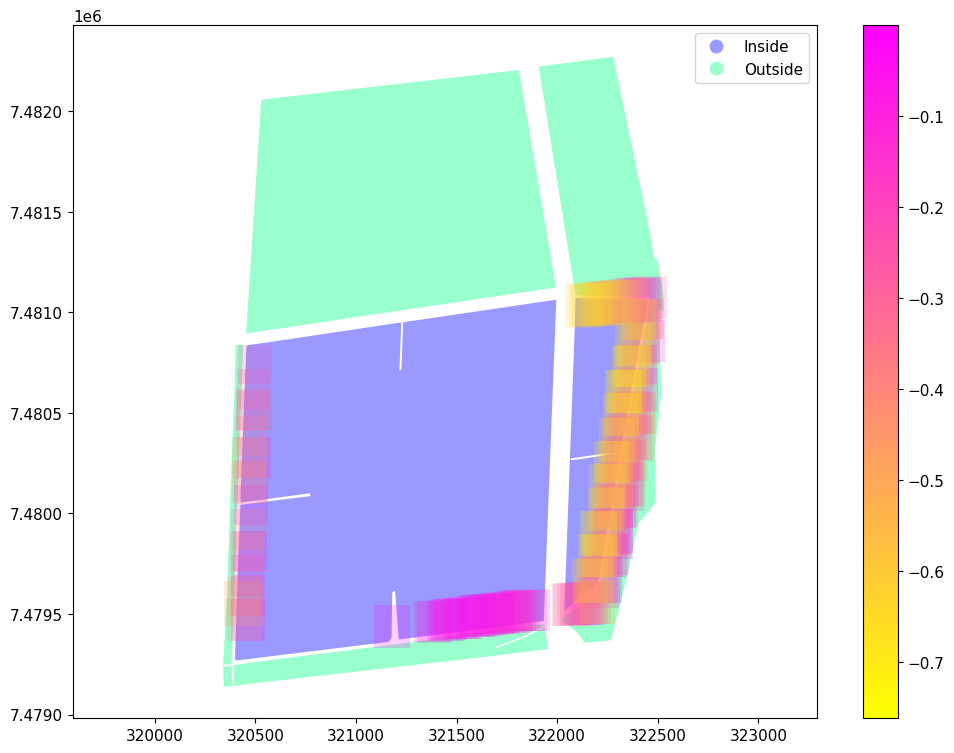

In [6]:
# Keep only the images that overlap multiple treatments
# Cutoff is that img has to overlap at least 100 m2 
# img_gdf['OverlapsTreatments'] = img_gdf.filter(like='Area').apply(lambda x: np.sum(x>100) > 1, axis=1)
# img_gdf_filter = img_gdf.loc[img_gdf['OverlapsTreatments']]

# Keep only the images that overlap multiple treatments
# (Cutoff is that img has to overlap at least 100 m2)
# Edited 7/5/2022 to only count images that overlap both inside and outside,
# Discluding polygons that overlap 2 polygons, but both polygons are the same treatment
img_gdf['OverlapsInside'] = img_gdf.filter(like='Area Inside').apply(lambda x: np.sum(x>1000) > 0, axis=1)
img_gdf['OverlapsOutside'] = img_gdf.filter(like='Area Outside').apply(lambda x: np.sum(x>1000) > 0, axis=1)
img_gdf_filter = img_gdf.loc[img_gdf['OverlapsInside'] & img_gdf['OverlapsOutside']]

from pathlib import Path

def has_grid_metrics(img_path):
    name = Path(img_path).stem
    coverd2f = Path(gridmetricdir) / name / f"{name}_CoverD2.nc"
    paid2f = Path(gridmetricdir) / name / f"{name}_FHPD2.nc"
    return coverd2f.exists() and paid2f.exists()

print("Images before grid-metric filtering:", len(img_gdf_filter))

img_gdf_filter = img_gdf_filter.loc[
    img_gdf_filter["img"].apply(has_grid_metrics)
].copy()

print("Images after grid-metric filtering:", len(img_gdf_filter))
print("Remaining image names:")
print([Path(f).stem for f in img_gdf_filter["img"].values])

fig, ax = plt.subplots()
# for img in pixel_dict['pixels_xr'][1]:
#     img.plot(ax=ax, alpha=0.3)

ax.axis('equal')
# clipbox.plot(ax=ax, alpha=0.3)
shp.plot(ax=ax, column='Treatment',
         legend=True, cmap='winter',
         alpha=0.4)
img_gdf.plot(ax=ax, alpha=0.2, cmap='spring_r', column='Evenness', legend=True)

plt.savefig(f'{figdir}/ImageSelection_AllImagesbyEvenness_{projstr}.jpg', dpi=300)

### Step 2 - Choose a random set of images that do not overlap with each other

In [7]:
# Output dict of filenames, their bounding polygons, and their pixel xarrays 
# nested in a dict with the shapefile ids as keys
pixel_dict = {'imgf':{}.fromkeys(shp.index, []), 
              'pixels_xr':{}.fromkeys(shp.index, []),
              'x_xr':{}.fromkeys(shp.index, []),
              'y_xr':{}.fromkeys(shp.index, []),
              'z_xr':{}.fromkeys(shp.index, []),
              'h_xr':{}.fromkeys(shp.index, []),
              'Exclosure':{}.fromkeys(shp.index, []),
              'Polygon':{}.fromkeys(shp.index, []),
              'Topo':{}.fromkeys(shp.index, []),
              'cd_xr':{}.fromkeys(shp.index, []),
              'pai_xr':{}.fromkeys(shp.index, [])
              }


# Edited 7/5/2022 - don't need pixels_xr in img_dict, since it's in pixel_dict
img_dict = {'imgf':[], 'boundary_poly':[]}

# Catching warnings
# (rio's extra samples in photo color channels error, and geoseries index warning)
# doesn't work for everything...
# https://stackoverflow.com/questions/14463277/how-to-disable-python-warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    # Loop through each image
    for i, g in zip(img_gdf_filter.img.values,
                    img_gdf_filter.geometry.values):

        # Load image
        img = rioxr.open_rasterio(i,
                                  parse_coordinates=True,
                                  masked=True)

        # extract the temp band and convert to kelvin
        img_k = (img.sel(band=4)*0.04)

        # filter 0 degree C and below as nans
        img_k = img_k.where(img_k > 273.15)
        
        # Make a geodataframe to use below
        clipbox = gpd.GeoDataFrame(index=[0], crs='EPSG:32736', geometry=[g])

        # Check the image's overlap with all previous images that have been processed thusfar
        poly_gs = gpd.GeoSeries(data=img_dict['boundary_poly'], crs='EPSG:32736')
        poly_gs.intersects(g)

        # Get the areas of the intersections
        poly_gs_intersect = poly_gs.intersection(g)
        
        # Get the percentage overlap
        poly_overlapperc = poly_gs_intersect.area/g.area
        
        # If any of these values are >= threshold %, don't run the file
        # But if there's minimal overlap, pass it on 
        overlap_idx = np.any(poly_overlapperc >= threshold)
        
        if not(overlap_idx):
            
            img_dict['imgf'].append(str(i).split('/')[-1])   
            # Save the shapely polygon
            img_dict['boundary_poly'].append(g)

            # loop through features in shapefile
            for ID, feat in zip(shp.index, shp.geometry.values):
                
                # Open netcdf file associated with this treatment 
                # Get image name file i 
                name = str(i).split('/')[-1].split('.tif')[0]
                coverd2f = f'{gridmetricdir}/{name}/{name}_CoverD2.nc'
                PAId2f = f'{gridmetricdir}/{name}/{name}_FHPD2.nc'

                # Open canopy density for this exclosure
                CD = rioxr.open_rasterio(coverd2f,
                                          parse_coordinates=True,
                                          masked=True)
                
                # Subset to Canopy Density at 5 cm
                CD = CD[CD.z==0.05]
                
                # Open PAI
                PAI = rioxr.open_rasterio(PAId2f,
                                          parse_coordinates=True,
                                          masked=True)
                

                # Only get PAI above 0.05 m
                PAI = PAI[PAI.z>0.05]
                
                # Sum to get total
                PAI_sum = PAI.sum(dim='z')
                
                # Save to raster for qgis
                PAI_sum.rio.to_raster(f'{mast_path}/out/raster/{name}_PAIabove5cm.tif')
                
                # Save attributes from images and shapefiles in nested dict
                pixel_dict['imgf'][ID].append(str(i).split('/')[-1])
                pixel_dict['Exclosure'][ID].append(shp.loc[ID].Treatment)
                pixel_dict['Topo'][ID].append(shp.loc[ID].TopoPositi)
                pixel_dict['Polygon'][ID].append(feat)

                # Get the intersection, and clip your raster with it
                if clipbox.intersects(feat)[0]:
                    
                    pixels = img_k.rio.clip(clipbox.intersection(feat), drop=True)     

                    # # # Save lidar data in dict as well for later comparison
                    
                    # Use rio.reproject_match to cut out relevant area of the CHM, DTM, and CD
                    # and resample onto the same grid with same spatial res (0.5 m)
                    CHM_match = CHM.rio.reproject_match(pixels)
                    DTM_match = DTM.rio.reproject_match(pixels)
                    CD_match = CD.rio.reproject_match(pixels)
                    PAI_match = PAI_sum.rio.reproject_match(pixels)
                    
                    
                    # Also, get the x,y coordinates of the pixels 
                    # (enables nearest tree analysis, etc., later)
                    yy, xx = np.meshgrid(pixels.y.values, pixels.x.values, indexing="ij")
                    x = xr.DataArray(xx, dims=["y", "x"], coords={"x": pixels.x, "y": pixels.y})
                    y = xr.DataArray(yy, dims=["y", "x"], coords={"x": pixels.x, "y": pixels.y})
                    
                    # Last, get the Clidar metric values for all the pixels
                    h = CHM_match.rio.clip(clipbox.intersection(feat), drop=True)
                    z = DTM_match.rio.clip(clipbox.intersection(feat), drop=True)
                    cd = CD_match.rio.clip(clipbox.intersection(feat), drop=True)
                    pai = PAI_match.rio.clip(clipbox.intersection(feat), drop=True)
                    
                else:
                    
                    pixels=[]
                    x=[]
                    y=[]
                    z=[]
                    h=[]
                    pai=[]
                    cd=[]
                    n=0
                    
                # Store all pixels in the nested dictionary
                pixel_dict['pixels_xr'][ID].append(pixels)
                pixel_dict['x_xr'][ID].append(x)
                pixel_dict['y_xr'][ID].append(y)
                pixel_dict['z_xr'][ID].append(z)
                pixel_dict['h_xr'][ID].append(h)
                pixel_dict['cd_xr'][ID].append(cd)
                pixel_dict['pai_xr'][ID].append(pai)

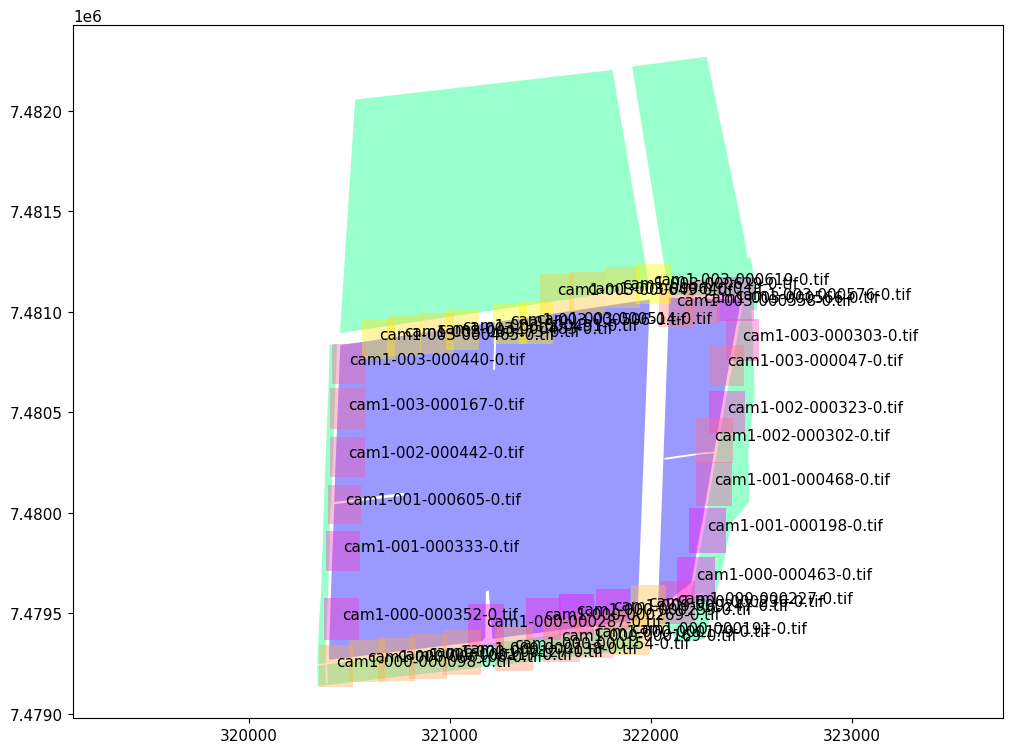

In [8]:
# Plot when done to get a sense of images and locations

# NOTE: need to re-subset polygs with dropflag
poly_gs = gpd.GeoSeries(data=img_dict['boundary_poly'], crs='EPSG:32736')

fig, ax = plt.subplots()
# for img in pixel_dict['pixels_xr'][1]:
#     img.plot(ax=ax, alpha=0.3)

ax.axis('equal')
# clipbox.plot(ax=ax, alpha=0.3)
shp.plot(ax=ax, cmap='winter', alpha=0.4, column='Treatment')
poly_gs.plot(ax=ax, alpha=0.4, cmap='spring')

labels = [str(s) for s in np.array(img_dict['imgf'])]

for cx, cy, t in zip(poly_gs.centroid.x.values, poly_gs.centroid.y.values, labels):
    ax.text(cx, cy, t)
    
fig.savefig(f'{figdir}/FinalImageOverlap_{projstr}.png', dpi=300)

In [9]:
# Initialize df list for loop
df_list = []

# For each polygon treatment in the shapefile
for ID in shp.index:
    
    # For each image
    for i, img in enumerate(pixel_dict['imgf'][ID]):
        
        df = pd.DataFrame()
        
        # If there are pixels for this treatment (it's NOT an empty list)
        if len(pixel_dict['pixels_xr'][ID][i])!=0:
            
            # Make an exploded dataframe, with each pixel noted by it's treatment, topo, and imgfile
            df = pd.DataFrame({'Temperature':pixel_dict['pixels_xr'][ID][i].data.flatten() - 273.15,
                               'Height':pixel_dict['h_xr'][ID][i].data.flatten(),                         
                               'Elevation':pixel_dict['z_xr'][ID][i].data.flatten(),
                               'Exclosure':pixel_dict['Exclosure'][ID][i],
                               'Topo':pixel_dict['Topo'][ID][i],
                               'imgf':img,
                               'CanopyDensity':pixel_dict['cd_xr'][ID][i].data.flatten(),
                               'PAI':pixel_dict['pai_xr'][ID][i].data.flatten()})
            

            # Drop na rows
            df.dropna(axis=0, how='any', inplace=True)
            
            # store DataFrame in list
            df_list.append(df.copy(deep=True))

# Concat all the dfs to make a full df 
df_pixels = pd.concat(df_list, ignore_index=True, sort=False)

In [10]:
# Add Vegtype, and save outputs as pickles

# # using list comprehension
vs = [classifyVegType(h) for h in df_pixels.Height]
df_pixels['VegType'] = vs

# Also, add canopy density as a percent
df_pixels['CanopyDensityPercent'] = df_pixels.CanopyDensity*100

# Save output as pickle obj file
df_pixels.to_pickle(f'{mast_path}/out/pixelpickles/{projstr}_pixels.obj')

In [11]:
# Set the seaborn plot theme to default
# incorporates grey grid into background of figures
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(font_scale=1.35, style="ticks", rc=custom_params)

## Print Statistics and Plot

In [12]:
nLow = df_pixels.Topo.loc[df_pixels.Topo=='Lowland'].shape[0]
nUp = df_pixels.Topo.loc[df_pixels.Topo=='Upland'].shape[0]
print(f'Lowland: {nLow}, Upland: {nUp}')

nFull = df_pixels.Topo.loc[df_pixels.Exclosure=='Inside'].shape[0]
nOpen = df_pixels.Topo.loc[df_pixels.Exclosure=='Outside'].shape[0]
print(f'Open: {nOpen}, Full: {nFull}')

Lowland: 19139730, Upland: 42325960
Open: 25981860, Full: 35483830


In [13]:
df_stats = df_pixels.groupby(['imgf', 'Topo', 'Exclosure']).describe()
df_stats.to_csv(f'{mast_path}/data/out/{projstr}_stats.csv')

In [14]:
df_pixels.groupby(['imgf', 'Topo', 'Exclosure']).mean()

TypeError: Could not convert ... to numeric

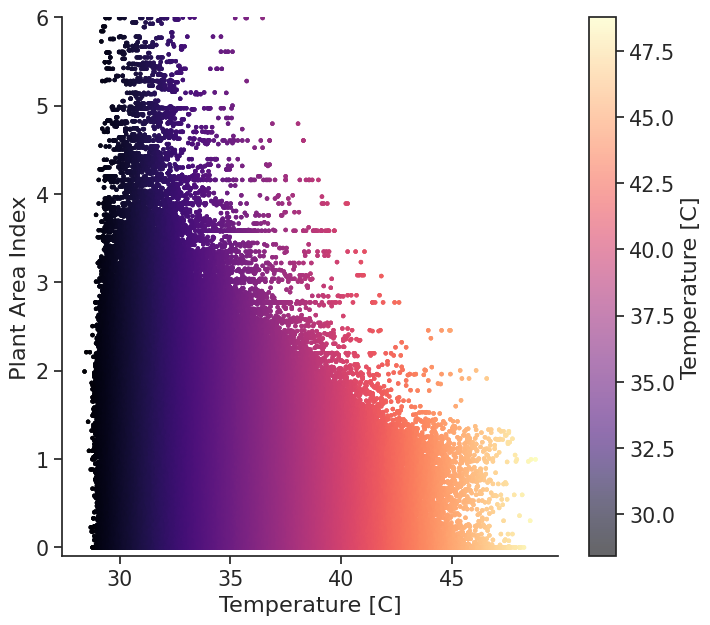

In [15]:
# # makes matplotlib plots big
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

df_pixels_0p1m = df_pixels.loc[df_pixels.Height >= 0.1]

a = ax.scatter(x=df_pixels_0p1m.Temperature,
               y=df_pixels_0p1m.PAI,
               c=df_pixels_0p1m.Temperature,
               alpha=0.6, cmap='magma', s=10, marker='o',
               edgecolors='none')

fig.colorbar(a, label='Temperature [C]')

ax.set_ylim(-0.1, 6)

# ax.set_xlim(33, 55)

ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Plant Area Index')

fig.savefig(f'{figdir}/ScatterPlot_TempxPAI_{projstr}_XYlimited.jpg', dpi=300)

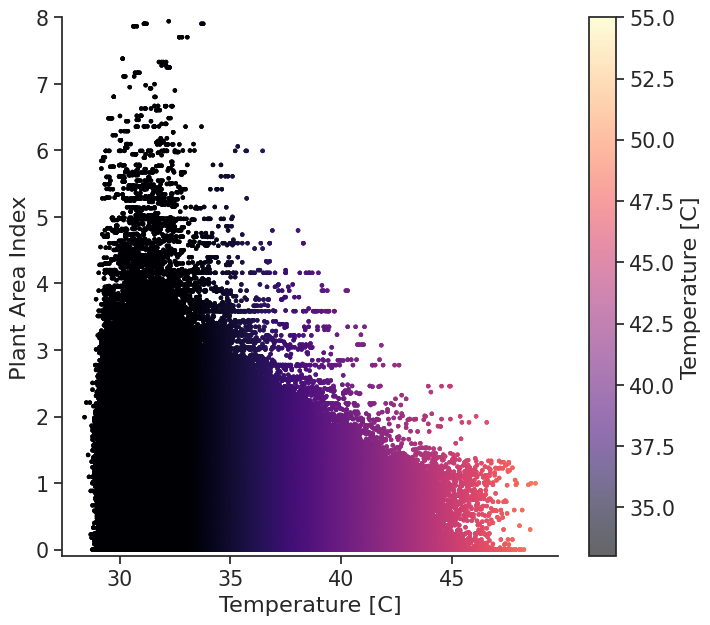

In [16]:
# # makes matplotlib plots big
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

df_pixels_0p1m = df_pixels.loc[df_pixels.Height >= 0.1]

a = ax.scatter(x=df_pixels_0p1m.Temperature,
               y=df_pixels_0p1m.PAI,
               c=df_pixels_0p1m.Temperature,
               alpha=0.6, cmap='magma', s=10, marker='o',
               edgecolors='none',
               vmin=33,
               vmax=55)

fig.colorbar(a, label='Temperature [C]')

ax.set_ylim(-0.1, 8)

#ax.set_xlim(33, 55)

ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Plant Area Index')

fig.savefig(f'{figdir}/ScatterPlot_TempxPAI_{projstr}_XYlimited.jpg', dpi=300)

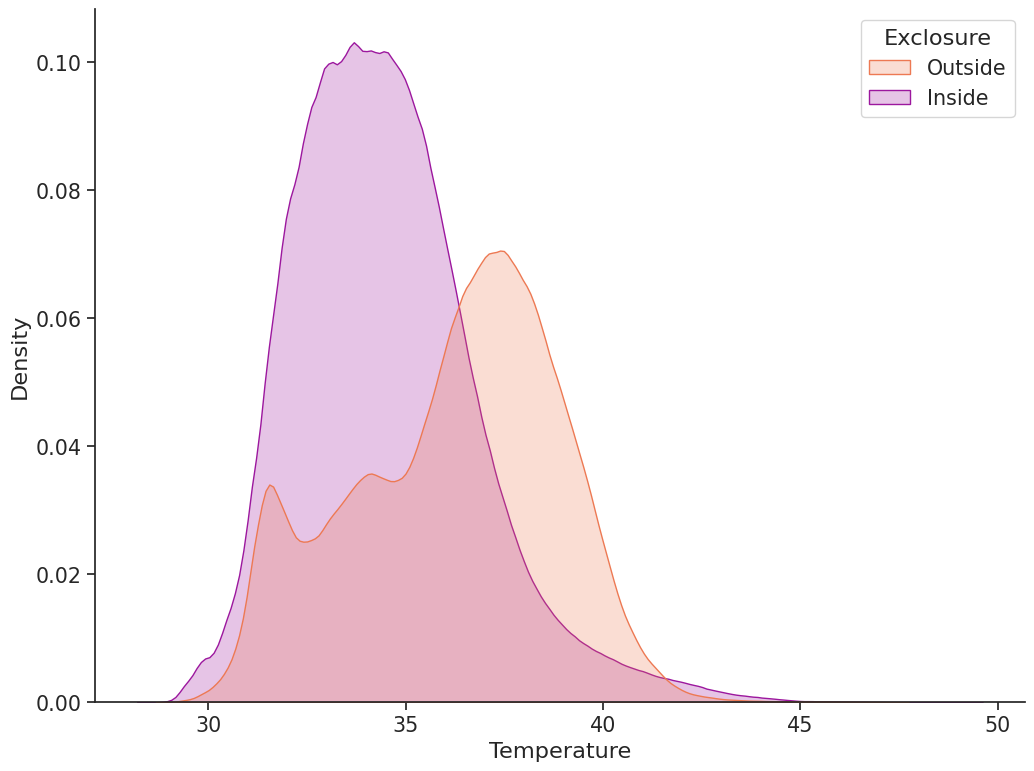

In [17]:
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots()
sns.kdeplot(data=df_pixels, x='Temperature', hue='Exclosure', ax=ax,
            palette='plasma_r', fill=True, hue_order=exclosure_hues)
fig.savefig(f'{figdir}/KDEplot_Exclosure_{projstr}.png', dpi=300)

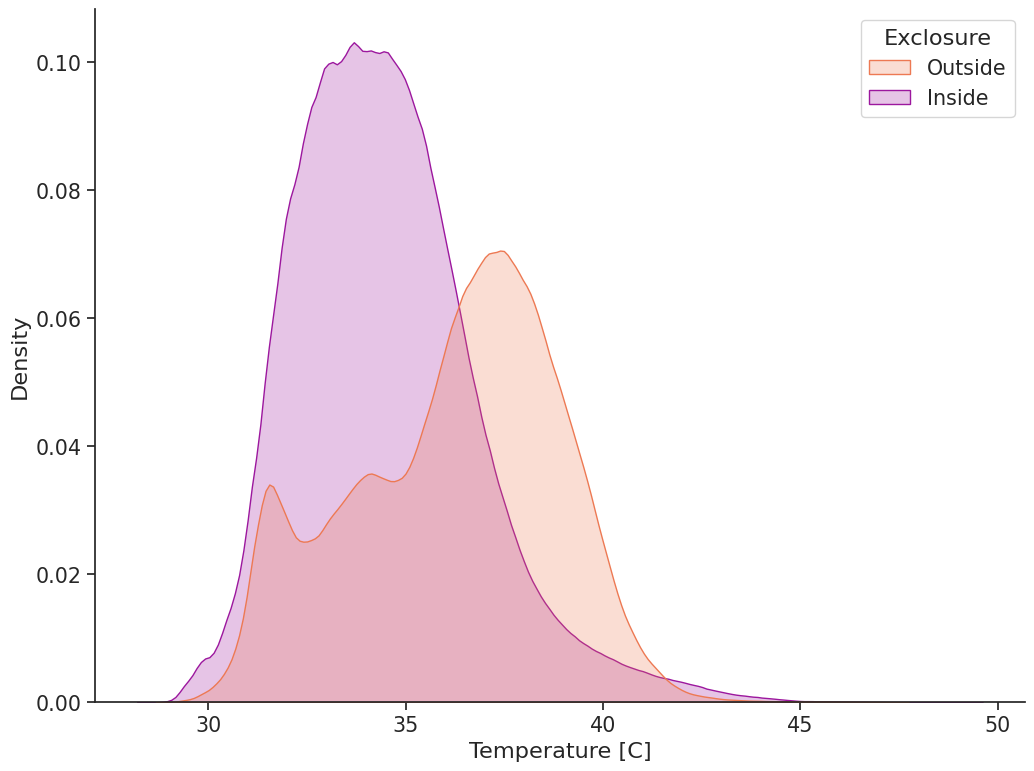

In [18]:
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots()
sns.kdeplot(data=df_pixels, x='Temperature', hue='Exclosure', ax=ax, palette='plasma_r',
            fill=True, hue_order=exclosure_hues)

#ax.set_xlim(24, 50)
ax.set_xlabel('Temperature [C]')

fig.savefig(f'{figdir}/KDEplot_Exclosure_Xlimited_{projstr}.jpg',
            dpi=300)

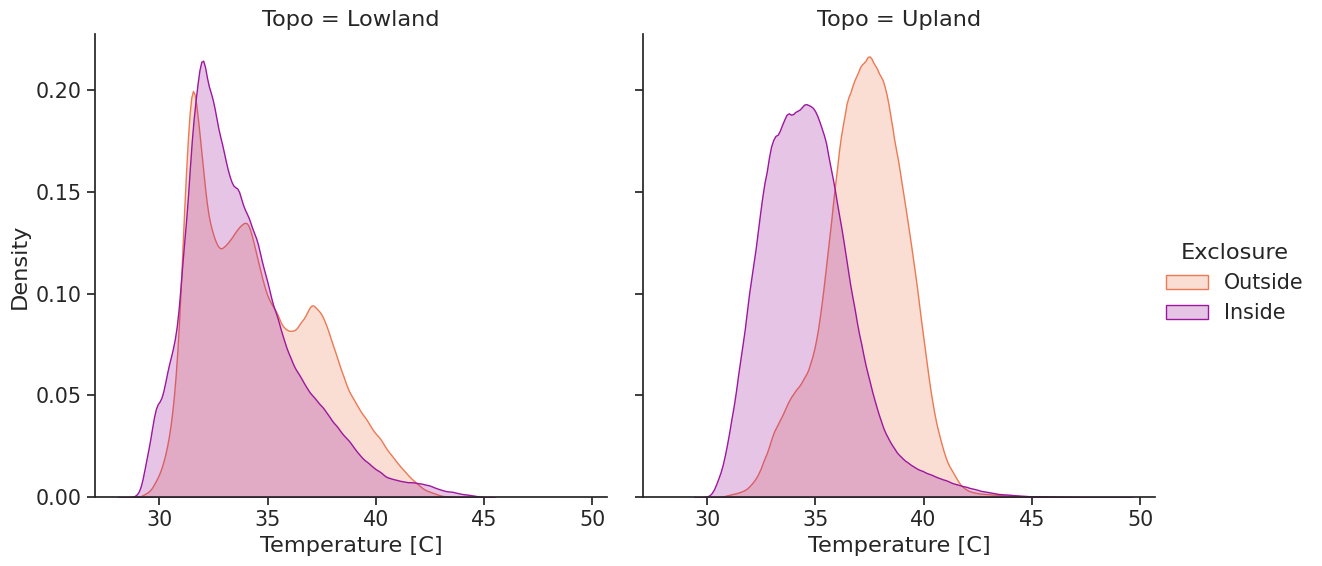

In [19]:
# Split by Lowland and Upland FacetGrid

# Use to dataframe to plot scatterplots of height v temp on a grid
FG = sns.FacetGrid(data=df_pixels, col='Topo', hue='Exclosure',
                   palette='plasma_r', hue_order=exclosure_hues,
                   col_order=['Lowland', 'Upland'], height=6)

FG.map_dataframe(sns.kdeplot, x='Temperature', fill=True)

FG.set_xlabels('Temperature [C]')
    
FG.set_ylabels('Density')
    
FG.add_legend()
#FG.set(xlim=(24, 50), ylim=(0, 0.55))

FG.savefig(f'{figdir}/KDEplot_TempbyExclosure_UpLowSplit_Xlimited_{projstr}.png',
           dpi=300)

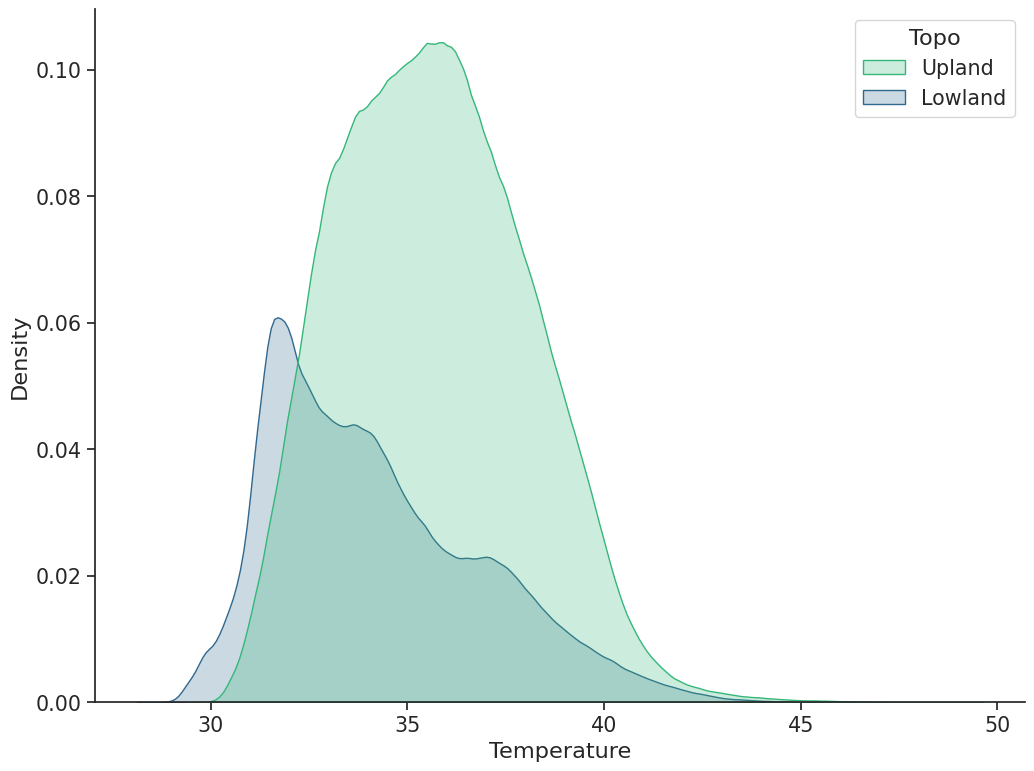

In [20]:
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots()
sns.kdeplot(data=df_pixels, x='Temperature', hue='Topo',
            ax=ax, palette='viridis_r', fill=True, hue_order=topo_hues)
fig.savefig(f'{figdir}/KDEplot_Topo_{projstr}.png', dpi=300)

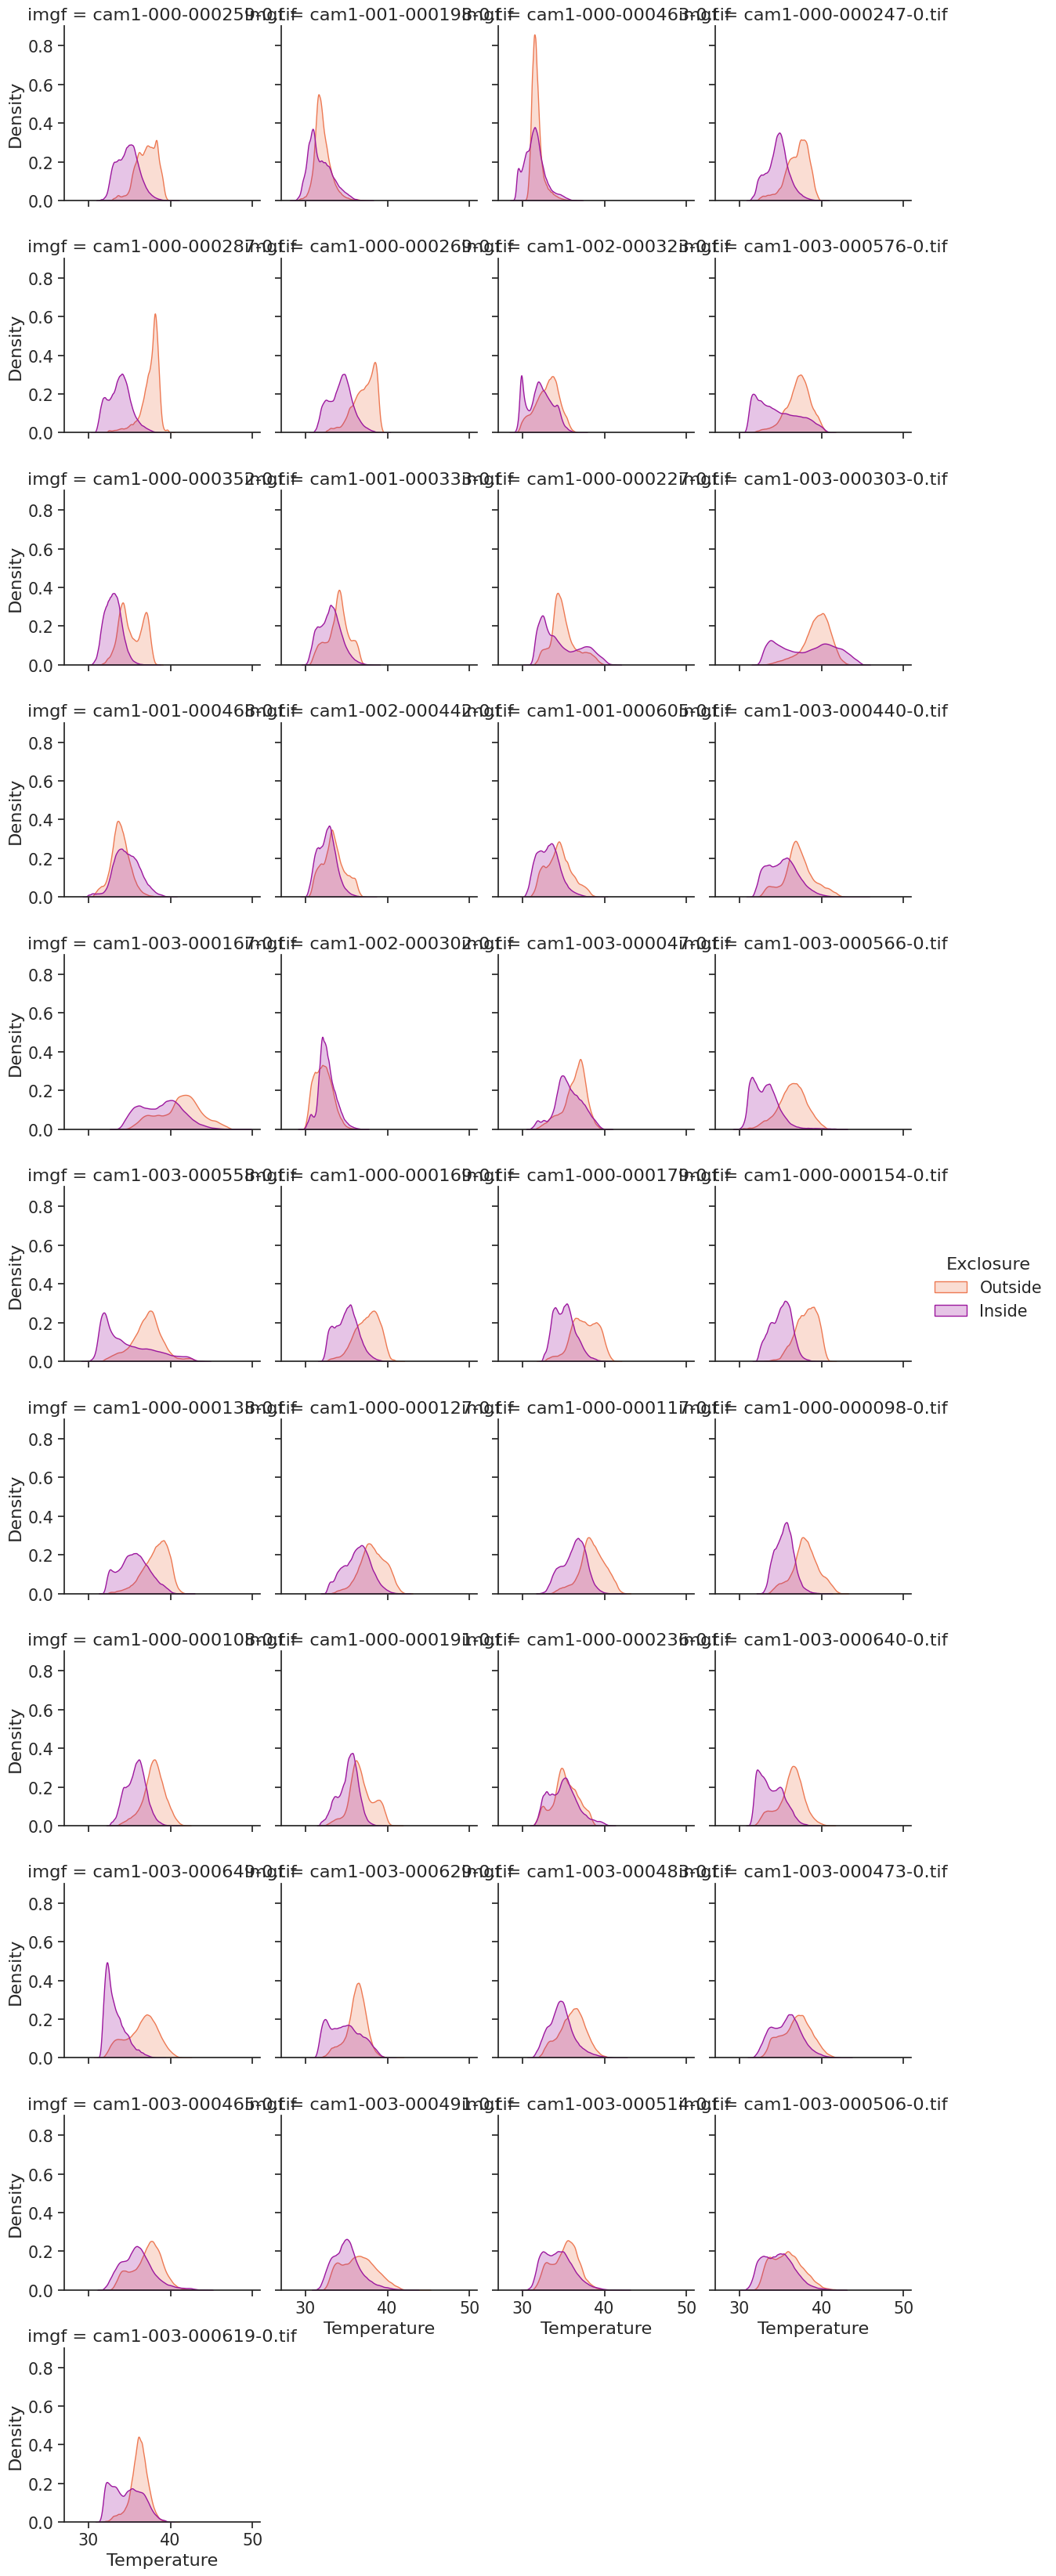

In [21]:
# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 10]
plt.rcParams.update({'font.size': 10})

# Use to dataframe to plot KDE plots in a facetgrid
FG = sns.FacetGrid(data=df_pixels, col='imgf', hue='Exclosure',
                   palette='plasma_r', col_wrap=4, hue_order=exclosure_hues)
FG.map_dataframe(sns.kdeplot, x='Temperature', fill=True)
FG.add_legend()
FG.tight_layout()
# ax.legend()


FG.savefig(f'{figdir}/KDEPlot_Exclosure_FacetGrid_{projstr}_byimg.png', dpi=300)

In [22]:
# Use to dataframe to plot KDE plots in a facetgrid
# sns.kdeplot(pixel_dict['pixels_xr'][ID][idx].data.flatten()-273.15, ax=ax)
# FG = sns.FacetGrid(data=df_pixels, col='Exclosure',  row='imgf')
# FG = sns.FacetGrid(data=df_pixels, row='Topo', col='imgf',
#                    hue='Exclosure', palette='plasma_r', hue_order=exclosure_hues)
# FG.map_dataframe(sns.kdeplot, x='Temperature', fill=True)
# FG.add_legend()
# # ax.legend()

# FG.savefig(f'{figdir}/KDEPlot_Topo_FacetGrid_{projstr}_byimg.png', dpi=300)

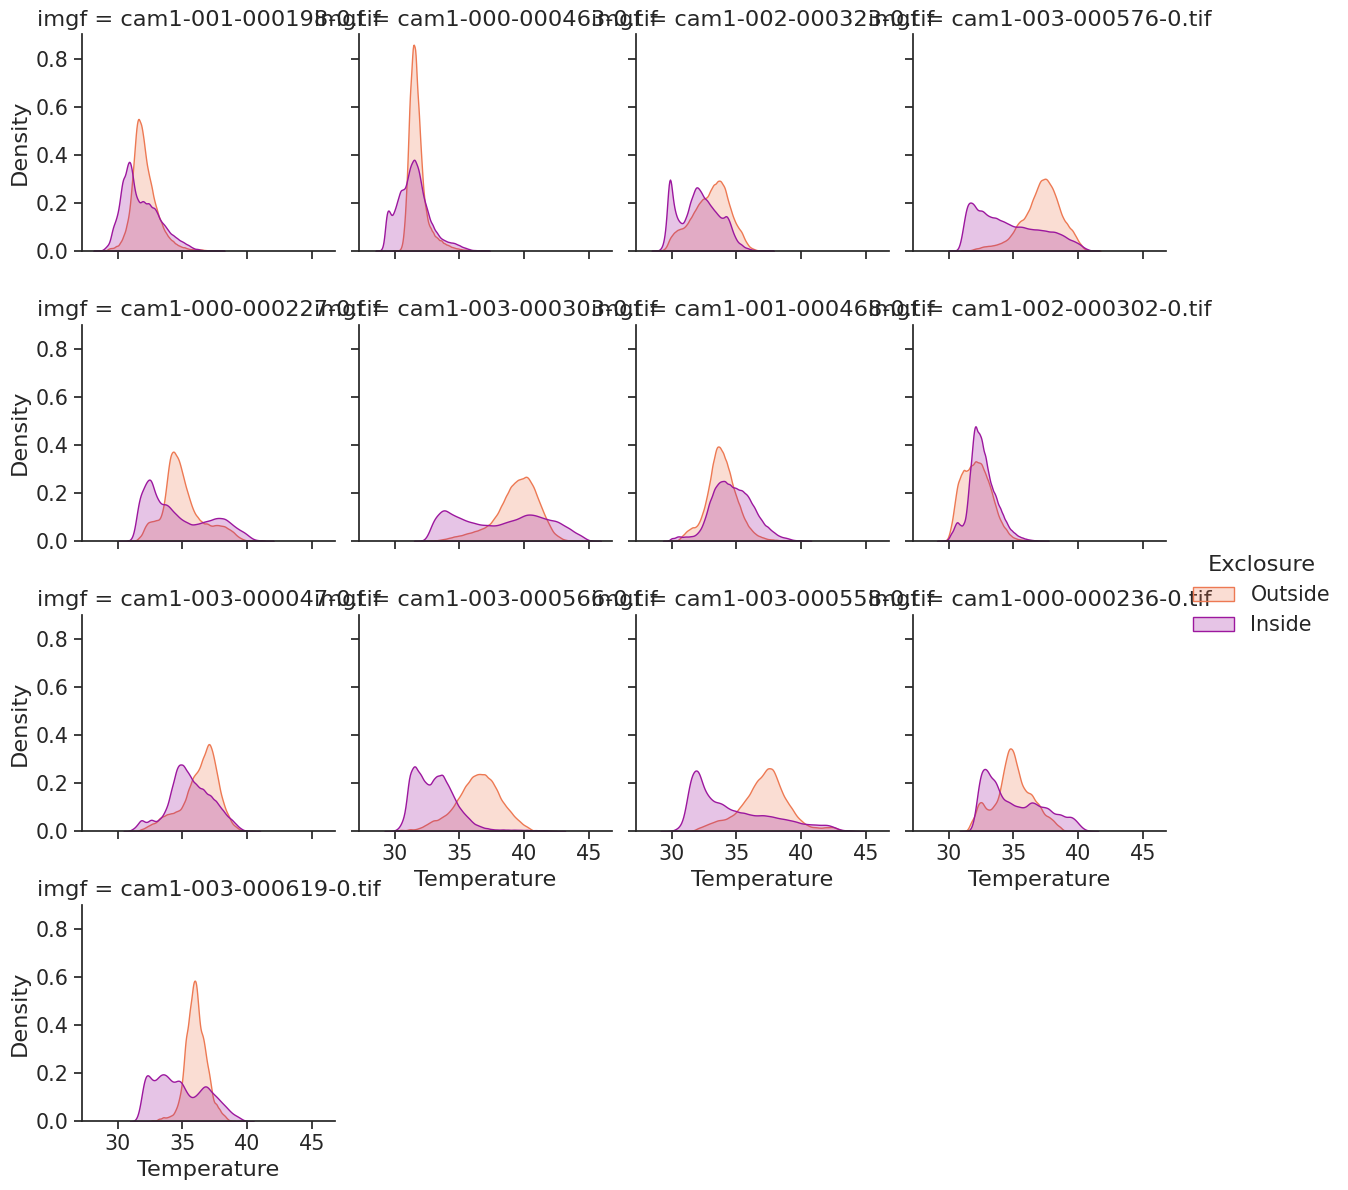

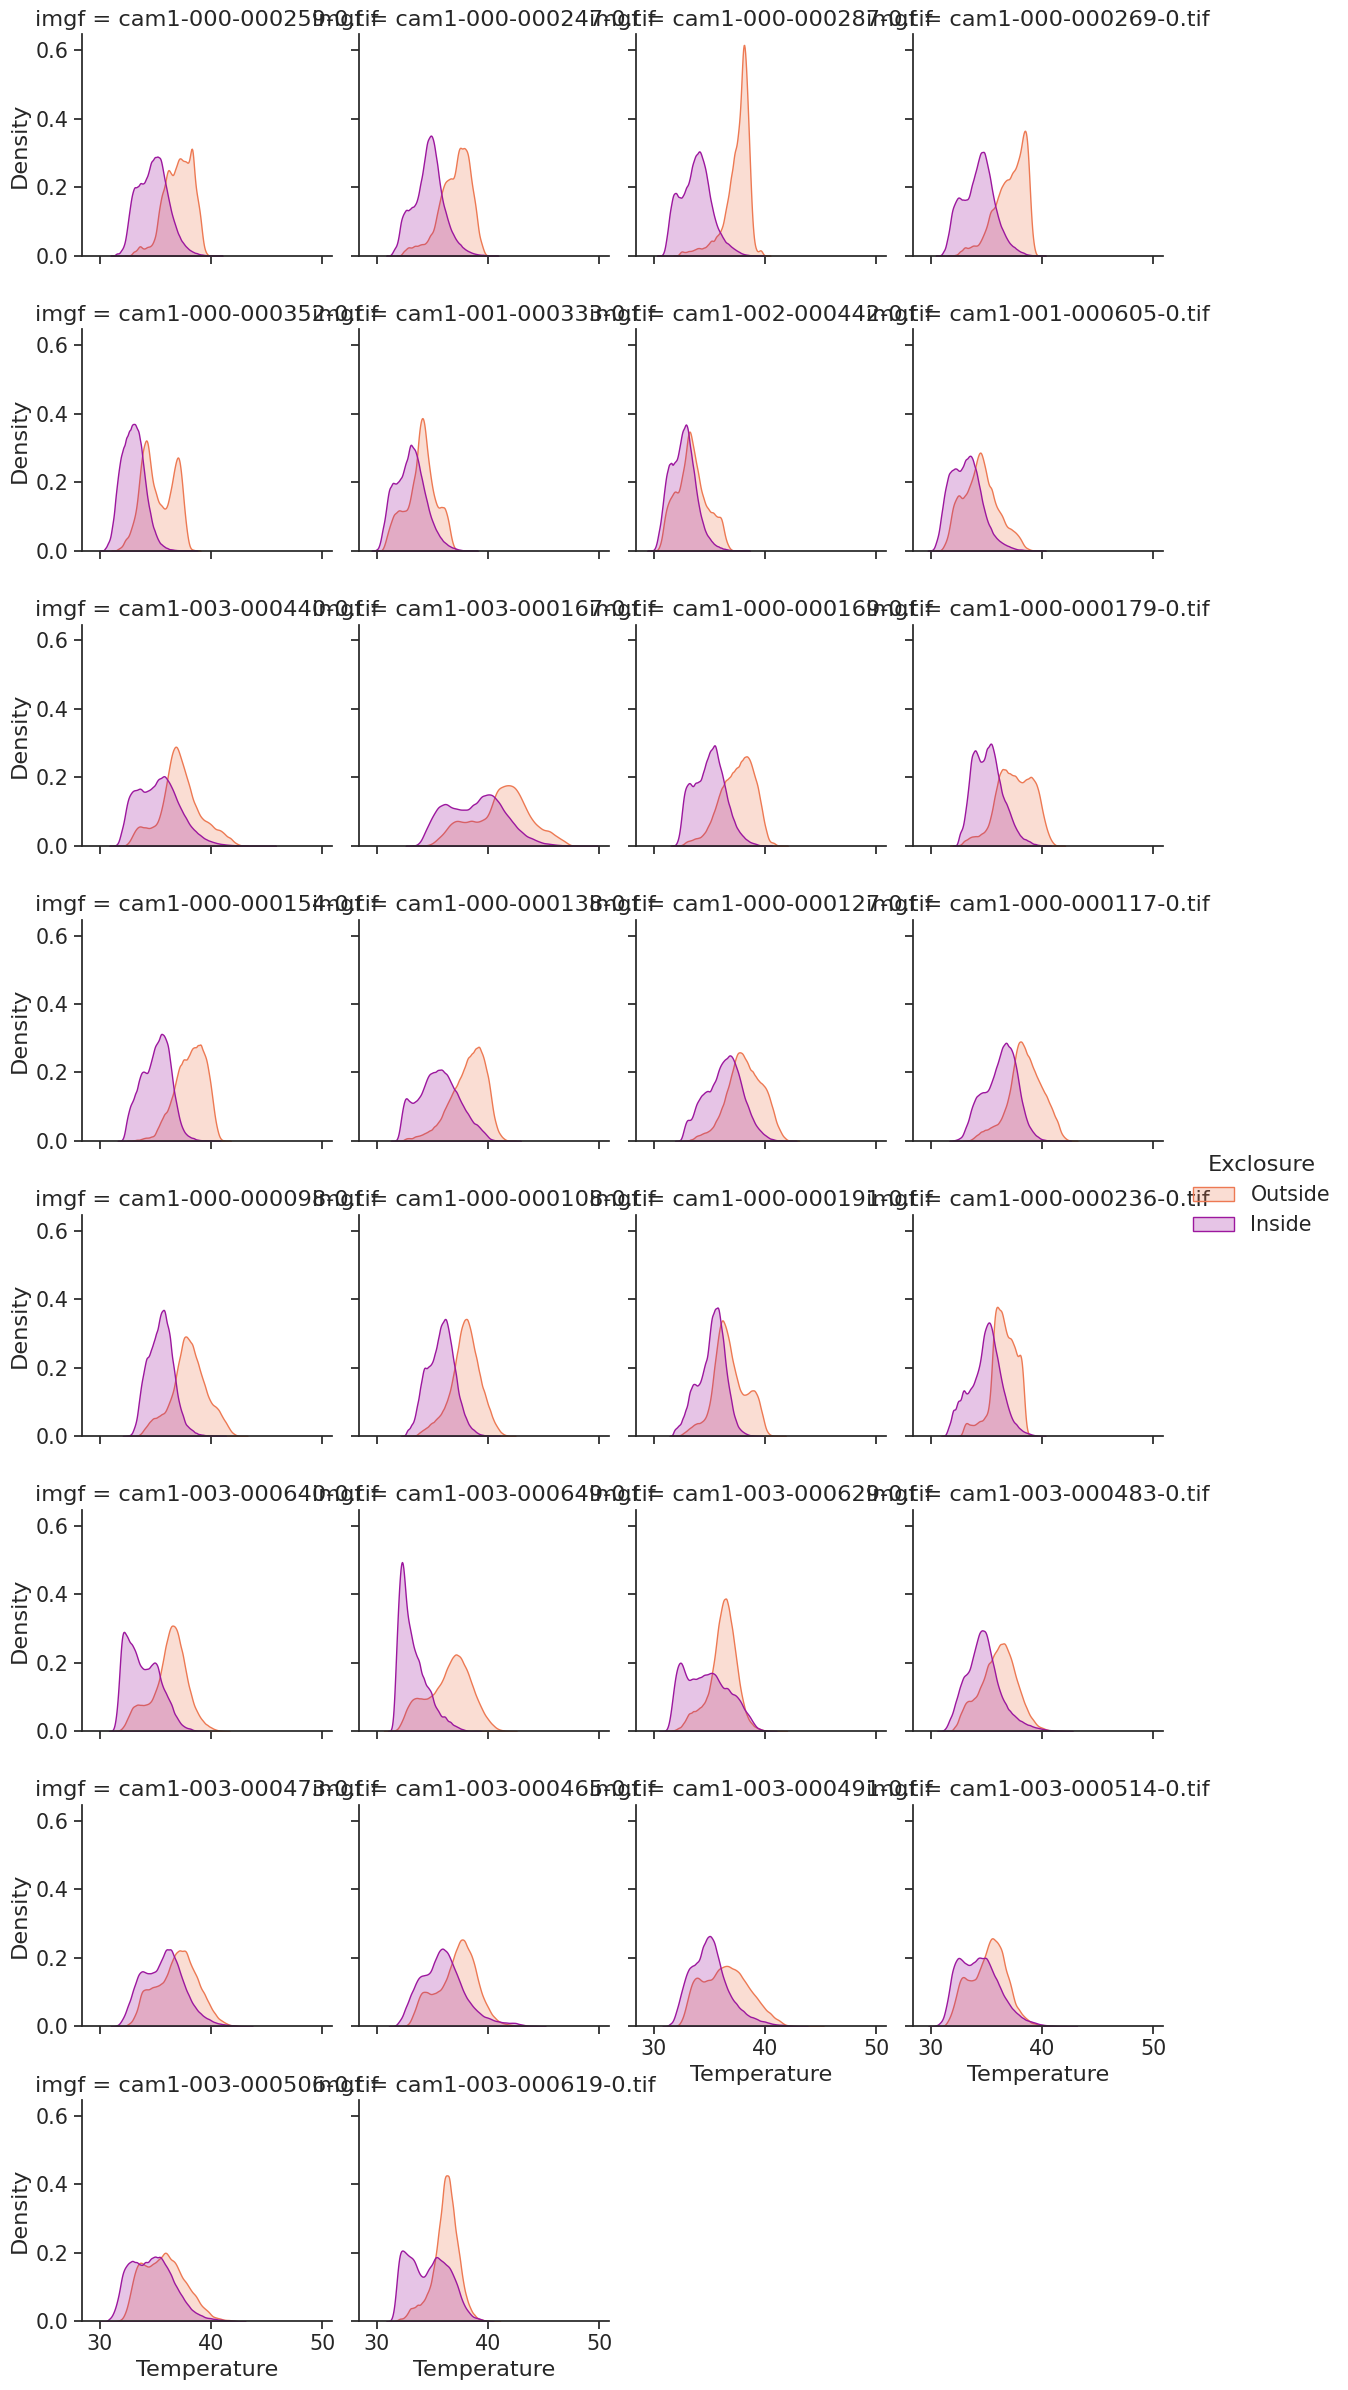

In [23]:
# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 10]
plt.rcParams.update({'font.size': 10})

# Plot Upland and Lowland in seperate Columns
for ul in ['Lowland', 'Upland']:
    
    # Use to dataframe to plot KDE plots in a facetgrid
    FG = sns.FacetGrid(data=df_pixels.loc[df_pixels['Topo']==ul], col='imgf',
                       hue='Exclosure', palette='plasma_r', col_wrap=4, hue_order=exclosure_hues)
    FG.map_dataframe(sns.kdeplot, x='Temperature', fill=True)
    FG.add_legend()
    
    FG.tight_layout()
    # ax.legend()

    FG.savefig(f'{figdir}/KDEPlot_{ul}_FacetGrid_{projstr}_byimg.png', dpi=300)

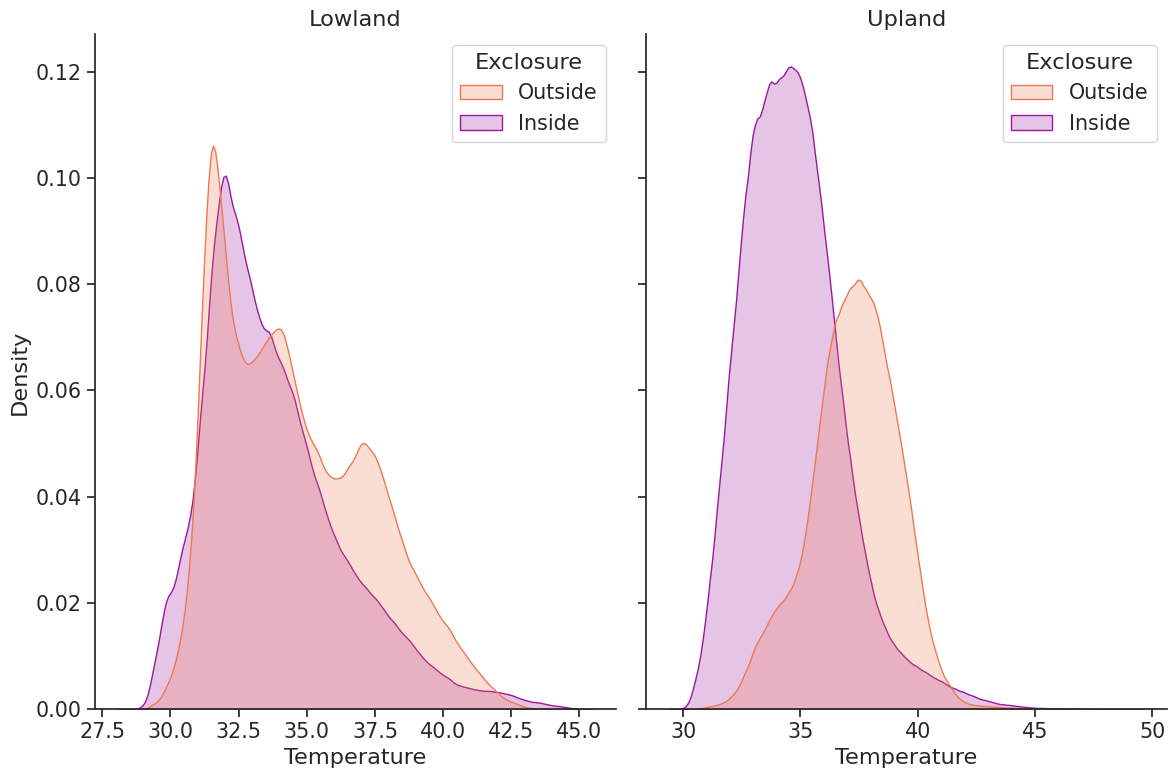

In [24]:
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams.update({'font.size': 14})
fig, (ax1, ax2) = plt.subplots(1,2, sharey=True)
# fig.savefig('{figdir}/KDEplot_Exclosure_Nkuhlu.png', dpi=300)

# Plot Upland and Lowland in seperate Columns
for ul, ax in zip(['Lowland', 'Upland'], [ax1, ax2]):
    
    sns.kdeplot(data=df_pixels.loc[df_pixels['Topo']==ul],
                x='Temperature',
                hue='Exclosure',
                ax=ax,
                palette='plasma_r',
                hue_order=exclosure_hues,
                fill=True)
                                   
    ax.set_title(f'{ul}')
    
fig.tight_layout()

fig.savefig(f'{figdir}/KDEPlot_Exclosure_UpLowSplit_{projstr}.png', dpi=300)